# Speed Dating Match Prediction

This notebook implements comprehensive model training for predicting speed dating matches.

Group Members:
- Vincent Chen (A69042679)
- Zih-Huan Kuang (A69029923)
- Yung-Chieh Yang (A16847470)

## Sections:
1. Setup and Data Loading
2. Data Analysis 
3. Baseline Models (Trivial and CSE258)
4. Advanced Models (Random Forest, XGBoost, Neural Network)
5. Model Comparison and Evaluation
6. Results and Conclusions


## 1. Setup and Data Loading


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

# Baseline Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Advanced Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Imbalance handling
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    print("Warning: imblearn not available. Will use alternative oversampling method.")
    SMOTE_AVAILABLE = False

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")


All libraries imported successfully!


### Load and Preprocess Data
Replicating the preprocessing steps from data_analysis.ipynb


In [2]:
# Load data
df = pd.read_csv("./speeddating.csv")
print(f"Original data shape: {df.shape}")

# Drop rows with too many missing values
df = df.dropna(thresh=0.9*len(df.columns))
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.4].index.tolist()
print(f"Dropping columns with > 40% missing: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)
print(f"After dropping missing: {df.shape}")

# Check class distribution
print(f"\nClass distribution:")
print(df['match'].value_counts())
print(f"Imbalance ratio: {df['match'].value_counts()[0] / df['match'].value_counts()[1]:.2f}:1")


Original data shape: (8378, 123)
Dropping columns with > 40% missing: ['expected_num_interested_in_me']
After dropping missing: (8155, 122)

Class distribution:
match
b'0'    6790
b'1'    1365
Name: count, dtype: int64
Imbalance ratio: 4.97:1


In [3]:
# Encode categorical columns
object_cols = df.select_dtypes(include=['object']).columns
object_cols = [c for c in object_cols if c != 'match']

encoder = OrdinalEncoder()
for col in object_cols:
    if df[col].nunique() < 10:
        df[col] = encoder.fit_transform(df[[col]])
        df[col] = df[col].astype(int)
    else:
        df = df.drop(columns=[col])  # Drop high cardinality columns

# Process target variable
df['match'] = df['match'].str.replace("b'", "").str.replace("'", "")
df['match'] = pd.to_numeric(df['match'], errors='coerce')

print(f"After encoding: {df.shape}")


After encoding: (8155, 121)


In [4]:
# Feature Engineering - Create interaction features
interactions = [
    ('pref_o_attractive', 'attractive_o', 'pref_attractive'),
    ('pref_o_sincere', 'sinsere_o', 'pref_sincere'),
    ('pref_o_intellicence', 'intelligence_o', 'pref_intellicence'),
    ('pref_o_funny', 'funny_o', 'pref_funny'),
    ('pref_o_ambtition', 'ambitous_o', 'pref_ambtition'),
    ('pref_o_shared_interests', 'shared_interests_o', 'pref_shared_interests'),
    ('attractive_important', "attractive_partner", "attr_imp_x_rating"),
    ('sincere_important', "sincere_partner", "sinc_imp_x_rating"),
    ('intellicence_important', "intelligence_partner", "intel_imp_x_rating"),
    ('funny_important', "funny_partner", "fun_imp_x_rating"),
    ('ambtition_important', "ambitious_partner", "amb_imp_x_rating"),
    ('shared_interests_important', "shared_interests_partner", "shar_imp_x_rating")
]

for imp, rating, new_col in interactions:
    if imp in df.columns and rating in df.columns:
        df[new_col] = df[imp] * df[rating]

print(f"Created {sum([1 for imp, rating, new_col in interactions if new_col in df.columns])} interaction features")


Created 9 interaction features


In [5]:
# Feature Scaling
float_cols = df.select_dtypes(include=['float']).columns
scaler = StandardScaler()
df[float_cols] = scaler.fit_transform(df[float_cols])

# Remove decision and decision_o to avoid data leakage (they perfectly predict match)
if 'decision' in df.columns:
    df = df.drop(['decision'], axis=1)
if 'decision_o' in df.columns:
    print("Note: 'decision_o' is kept as it represents partner's decision (important feature)")
    
print(f"Final preprocessed shape: {df.shape}")


Note: 'decision_o' is kept as it represents partner's decision (important feature)
Final preprocessed shape: (8155, 129)


## 2. Data Analysis

### Correlation Analysis

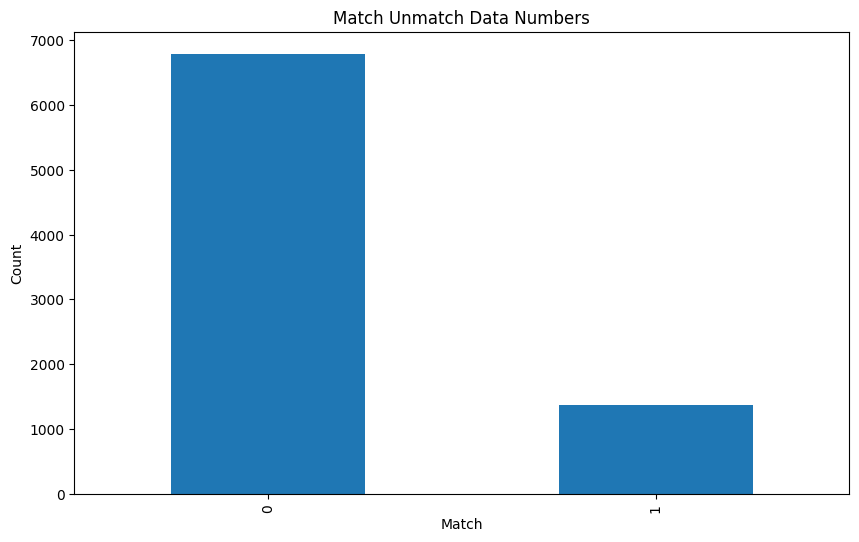

In [6]:
# Show match unmatch data numbers
# Data is unbalanced, so maybe we can try some undersampling or oversampling methods
# https://medium.com/@dakshrathi/handling-imbalanced-data-key-techniques-for-better-machine-learning-6e33b466f8b7
plt.figure(figsize=(10, 6))
df['match'].value_counts().plot(kind='bar')
plt.title('Match Unmatch Data Numbers')
plt.xlabel('Match')
plt.ylabel('Count')
plt.show()

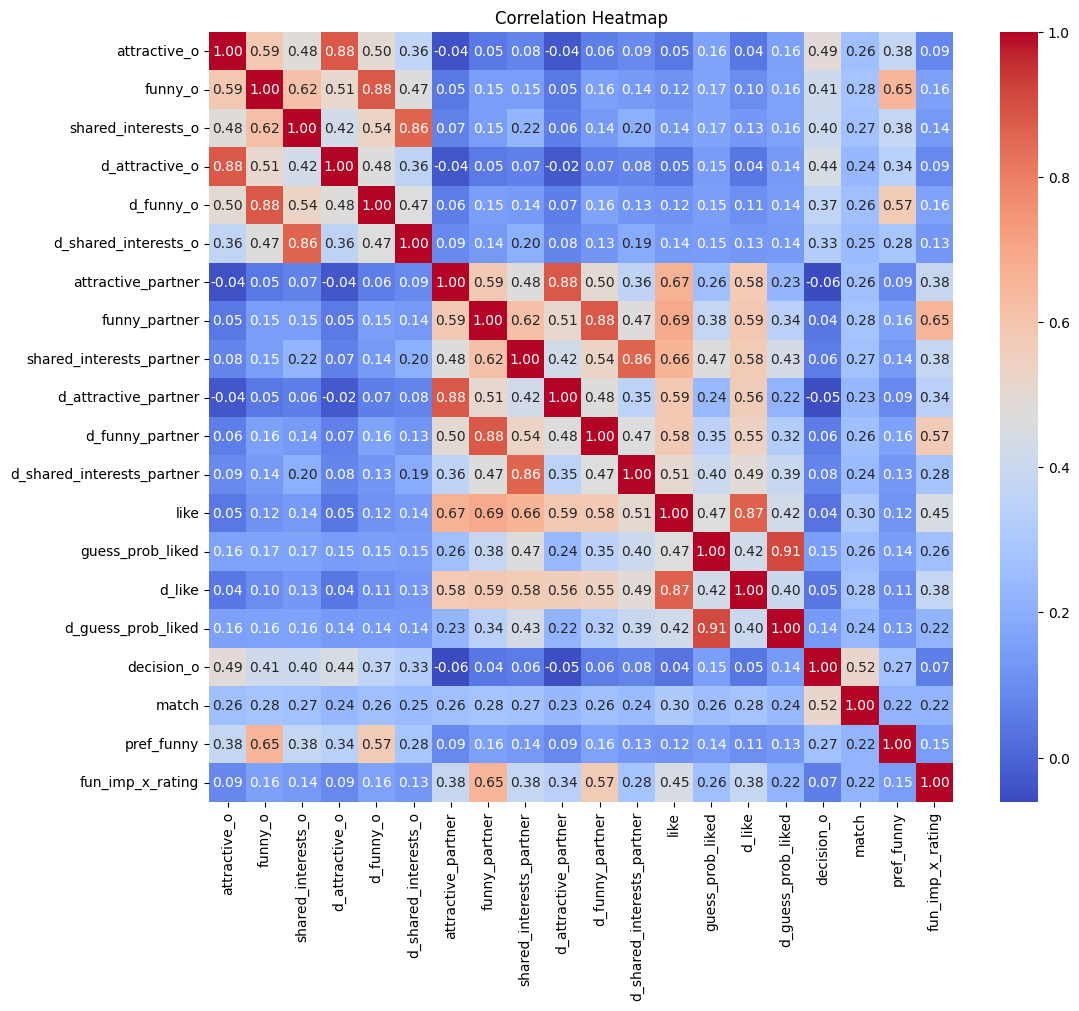

In [7]:
# Increase the figure size for better readability
plt.figure(figsize=(12, 10))
correlations = df.corr()['match']
top_features = correlations[correlations > 0.18].index

# Draw the heatmap
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
# plt.savefig("corr.png")

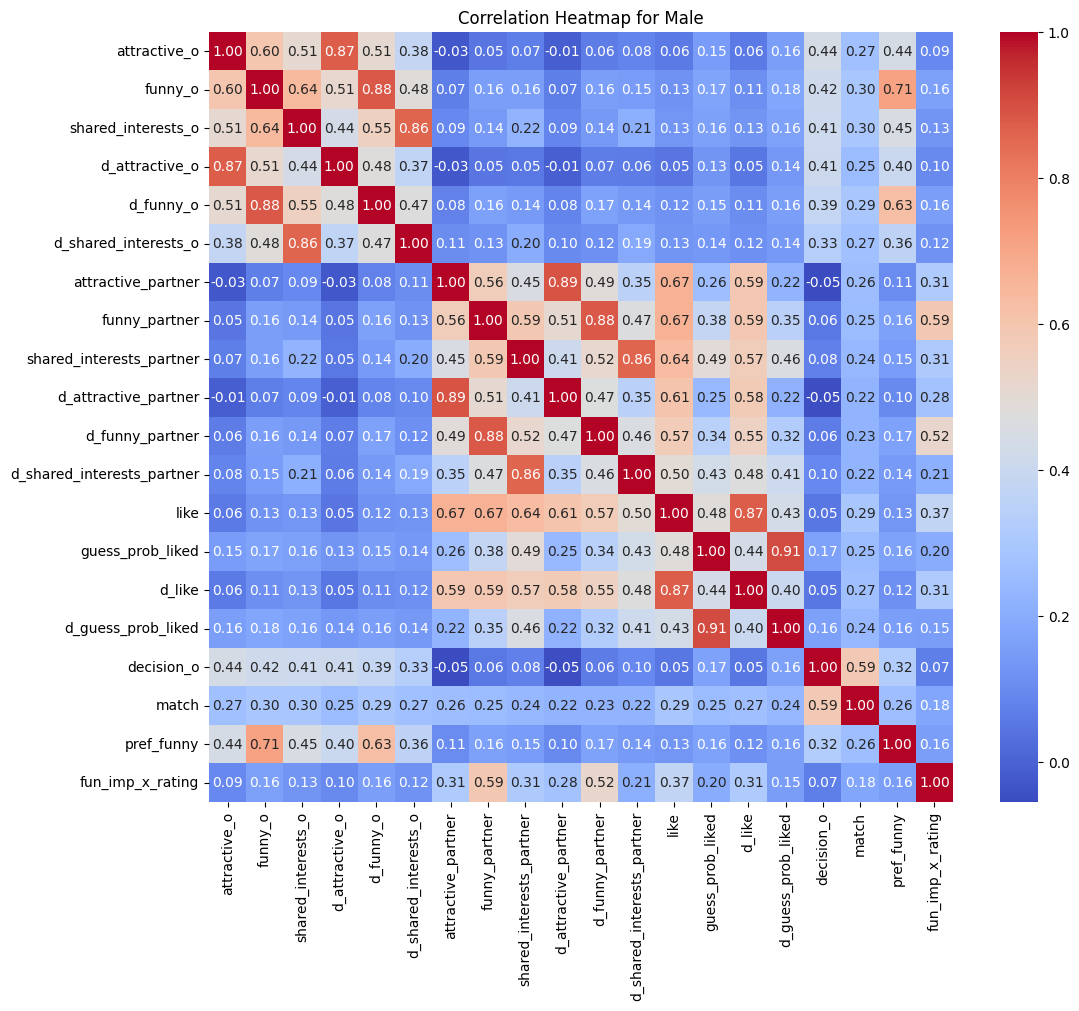

In [8]:
# Increase the figure size for better readability
plt.figure(figsize=(12, 10))
correlations = df[df["gender"] == 1].corr()['match']
top_features = correlations[correlations > 0.18].index

# Draw the heatmap
sns.heatmap(df[df["gender"] == 1][top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap for Male')
plt.show()
# plt.savefig("corr_male.png")

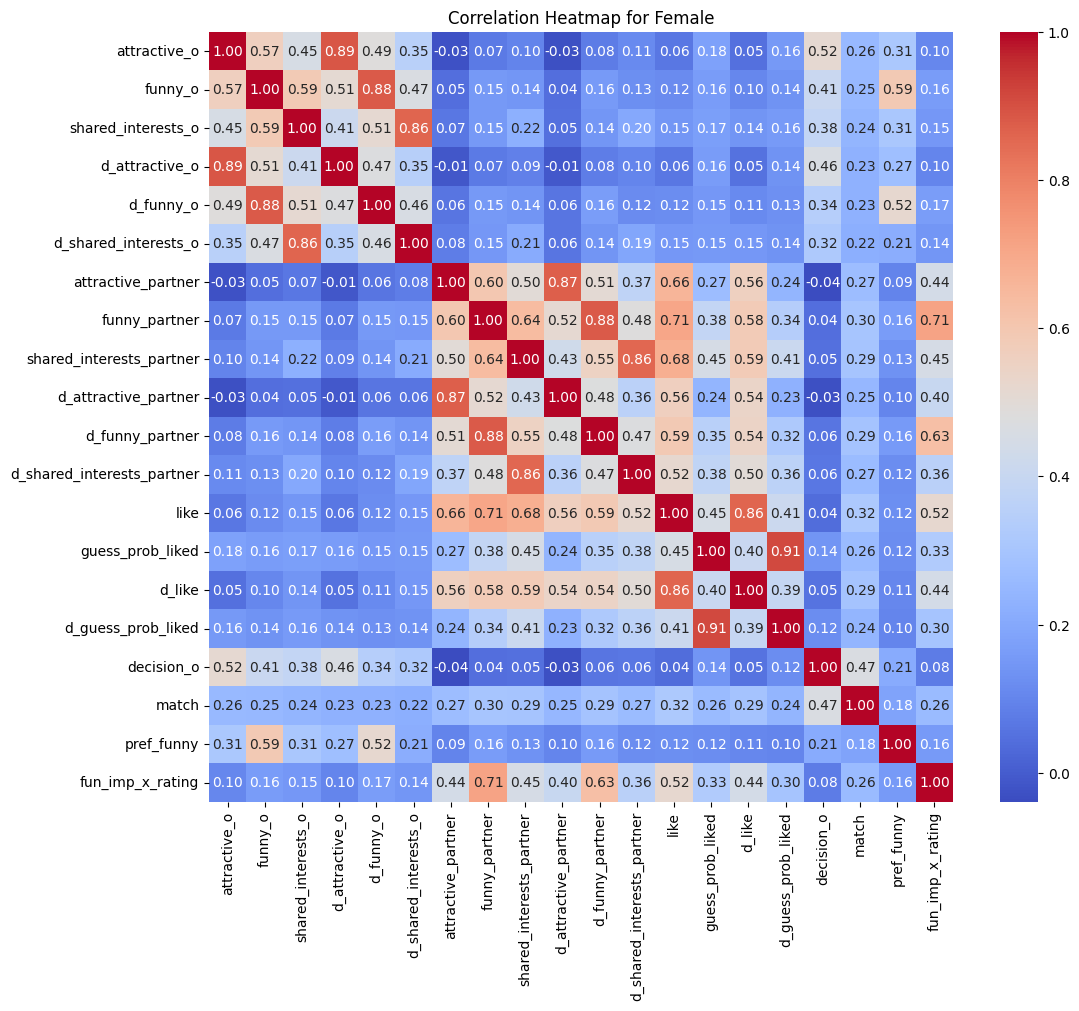

In [9]:
# Increase the figure size for better readability
plt.figure(figsize=(12, 10))
correlations = df[df["gender"] == 0].corr()['match']
top_features = correlations[correlations > 0.18].index

# Draw the heatmap
sns.heatmap(df[df["gender"] == 0][top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Heatmap for Female')
plt.show()
# plt.savefig("corr_female.png")

### Distribution Analysis

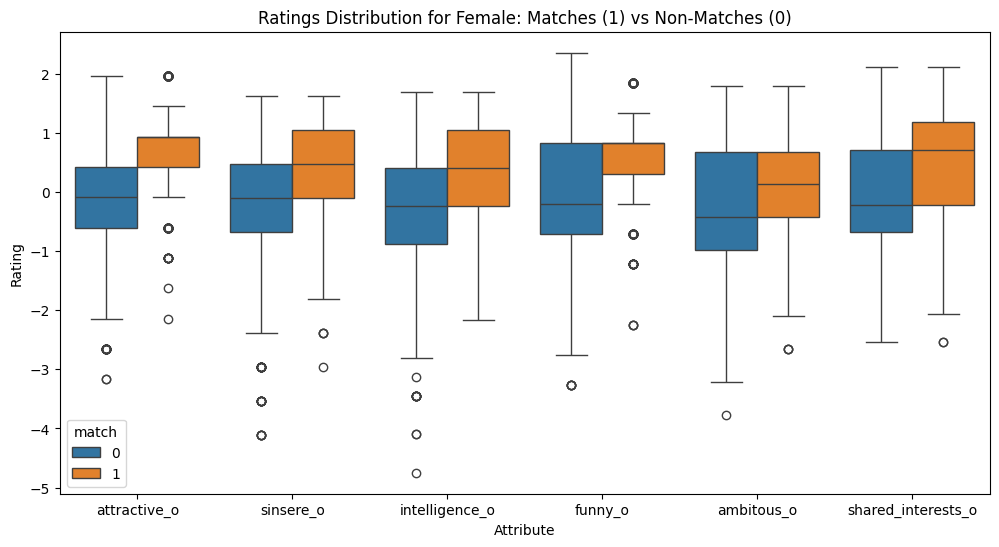

In [10]:
# Melt the data to compare multiple attributes side-by-side

cols_to_plot = ['attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o']
df_melted = df[df['gender'] == 0].melt(id_vars=['match'], value_vars=cols_to_plot, 
                    var_name='Attribute', value_name='Rating')

# Visualize the difference in ratings between Matches and Non-Matches
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Attribute', y='Rating', hue='match')
plt.title("Ratings Distribution for Female: Matches (1) vs Non-Matches (0)")
plt.show()

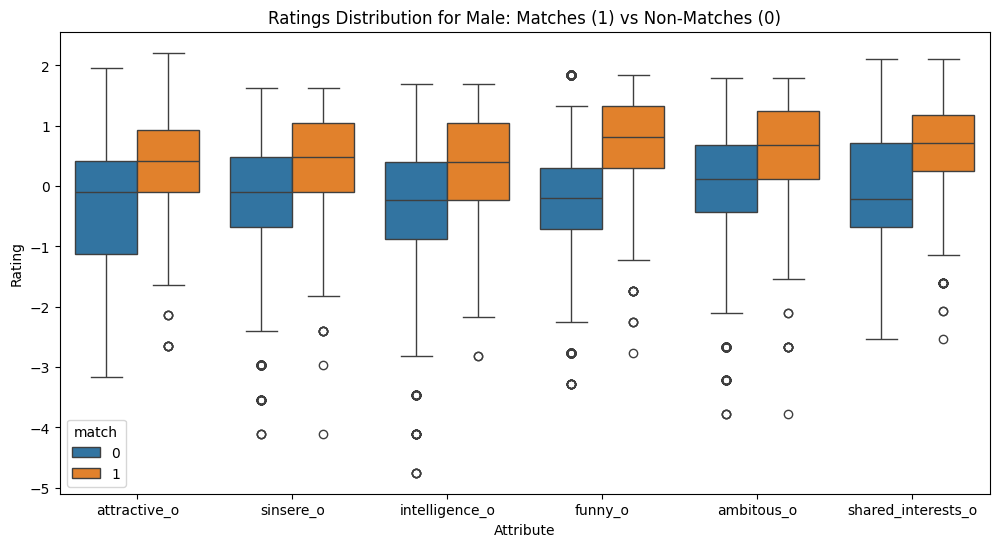

In [11]:
# Melt the data to compare multiple attributes side-by-side

cols_to_plot = ['attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o']
df_melted = df[df['gender'] == 1].melt(id_vars=['match'], value_vars=cols_to_plot, 
                    var_name='Attribute', value_name='Rating')

# Visualize the difference in ratings between Matches and Non-Matches
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Attribute', y='Rating', hue='match')
plt.title("Ratings Distribution for Male: Matches (1) vs Non-Matches (0)")
plt.show()

### Prepare Train/Test Split


In [12]:
# Separate features and target
X = df.drop(["match"], axis=1)
y = df["match"]

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Training class distribution:\n{y_train.value_counts()}")
print(f"Test class distribution:\n{y_test.value_counts()}")


Training set: (6524, 128), Test set: (1631, 128)
Training class distribution:
match
0    5432
1    1092
Name: count, dtype: int64
Test class distribution:
match
0    1358
1     273
Name: count, dtype: int64


In [13]:
# Store results for comparison
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': [],
    'CV_Mean': [],
    'CV_Std': []
}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, use_cv=True):
    """
    Evaluate a model and store results
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Cross-validation
    cv_mean, cv_std = None, None
    if use_cv:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
    
    # Store results
    results['Model'].append(model_name)
    results['Accuracy'].append(acc)
    results['Precision'].append(prec)
    results['Recall'].append(rec)
    results['F1-Score'].append(f1)
    results['ROC-AUC'].append(roc_auc)
    results['CV_Mean'].append(cv_mean)
    results['CV_Std'].append(cv_std)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Precision:      {prec:.4f}")
    print(f"Recall:         {rec:.4f}")
    print(f"F1-Score:       {f1:.4f}")
    if roc_auc:
        print(f"ROC-AUC:        {roc_auc:.4f}")
    if cv_mean:
        print(f"CV Accuracy:    {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return model

print("Evaluation function ready!")


Evaluation function ready!


## 2. Baseline Models

### 2.1 Trivial Baselines
These simple baselines provide a lower bound for model performance.


In [14]:
# Baseline 1: Majority Class (Always predict "no match")
majority_baseline = DummyClassifier(strategy='most_frequent')
evaluate_model(majority_baseline, X_train, X_test, y_train, y_test, 
               'Majority Class Baseline', use_cv=True)



Model: Majority Class Baseline
Test Accuracy:  0.8326
Precision:      0.0000
Recall:         0.0000
F1-Score:       0.0000
ROC-AUC:        0.5000
CV Accuracy:    0.8326 (+/- 0.0004)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      1358
           1       0.00      0.00      0.00       273

    accuracy                           0.83      1631
   macro avg       0.42      0.50      0.45      1631
weighted avg       0.69      0.83      0.76      1631



,strategy,'most_frequent'
,random_state,None
,constant,None


In [15]:
# Baseline 2: Random Prediction (stratified based on training class distribution)
random_baseline = DummyClassifier(strategy='stratified', random_state=42)
evaluate_model(random_baseline, X_train, X_test, y_train, y_test, 
               'Random Prediction Baseline', use_cv=True)



Model: Random Prediction Baseline
Test Accuracy:  0.7137
Precision:      0.1486
Recall:         0.1502
F1-Score:       0.1494
ROC-AUC:        0.4886
CV Accuracy:    0.7132 (+/- 0.0108)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1358
           1       0.15      0.15      0.15       273

    accuracy                           0.71      1631
   macro avg       0.49      0.49      0.49      1631
weighted avg       0.71      0.71      0.71      1631



,strategy,'stratified'
,random_state,42
,constant,None


In [16]:
# Baseline 3: Rule-based on single feature (decision_o - partner's decision)
# This is a strong single-feature baseline since partner's positive decision is highly correlated with match
if 'decision_o' in X_train.columns:
    # Simple rule: predict match if decision_o > threshold
    threshold = 0.5  # Since data is standardized
    y_pred_rule = (X_test['decision_o'] > threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred_rule)
    prec = precision_score(y_test, y_pred_rule)
    rec = recall_score(y_test, y_pred_rule)
    f1 = f1_score(y_test, y_pred_rule)
    
    # Perform cross-validation for rule-based method
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        y_pred_val = (X_val['decision_o'] > threshold).astype(int)
        cv_scores.append(accuracy_score(y_val, y_pred_val))
    cv_mean = np.mean(cv_scores)
    cv_std = np.std(cv_scores)
    
    results['Model'].append('Rule-based (decision_o)')
    results['Accuracy'].append(acc)
    results['Precision'].append(prec)
    results['Recall'].append(rec)
    results['F1-Score'].append(f1)
    results['ROC-AUC'].append(None)
    results['CV_Mean'].append(cv_mean)
    results['CV_Std'].append(cv_std)
    
    print(f"\n{'='*60}")
    print(f"Model: Rule-based (decision_o > {threshold})")
    print(f"{'='*60}")
    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Precision:      {prec:.4f}")
    print(f"Recall:         {rec:.4f}")
    print(f"F1-Score:       {f1:.4f}")
    print(f"CV Accuracy:    {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred_rule))
else:
    print("decision_o not in features")


Model: Rule-based (decision_o > 0.5)
Test Accuracy:  0.7357
Precision:      0.3878
Recall:         1.0000
F1-Score:       0.5589
CV Accuracy:    0.7440 (+/- 0.0125)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.68      0.81      1358
           1       0.39      1.00      0.56       273

    accuracy                           0.74      1631
   macro avg       0.69      0.84      0.69      1631
weighted avg       0.90      0.74      0.77      1631



### 2.2 CSE258 Model Baselines
Standard machine learning models taught in CSE258.


In [17]:
# Baseline 4: Logistic Regression
lr = LogisticRegression(max_iter=5000, random_state=42)
evaluate_model(lr, X_train, X_test, y_train, y_test, 'Logistic Regression')



Model: Logistic Regression
Test Accuracy:  0.9062
Precision:      0.7239
Recall:         0.7106
F1-Score:       0.7172
ROC-AUC:        0.9552
CV Accuracy:    0.9183 (+/- 0.0118)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1358
           1       0.72      0.71      0.72       273

    accuracy                           0.91      1631
   macro avg       0.83      0.83      0.83      1631
weighted avg       0.91      0.91      0.91      1631



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [18]:
# Baseline 5: Ridge Classifier
ridge = RidgeClassifier(random_state=42)
evaluate_model(ridge, X_train, X_test, y_train, y_test, 'Ridge Classifier')



Model: Ridge Classifier
Test Accuracy:  0.8976
Precision:      0.8011
Recall:         0.5165
F1-Score:       0.6281
CV Accuracy:    0.8987 (+/- 0.0054)

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1358
           1       0.80      0.52      0.63       273

    accuracy                           0.90      1631
   macro avg       0.86      0.75      0.78      1631
weighted avg       0.89      0.90      0.89      1631



,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,42


In [19]:
# Baseline 6: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train, X_test, y_train, y_test, 'K-Nearest Neighbors (k=5)')



Model: K-Nearest Neighbors (k=5)
Test Accuracy:  0.8326
Precision:      0.5000
Recall:         0.2784
F1-Score:       0.3576
ROC-AUC:        0.7235
CV Accuracy:    0.8329 (+/- 0.0042)

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1358
           1       0.50      0.28      0.36       273

    accuracy                           0.83      1631
   macro avg       0.68      0.61      0.63      1631
weighted avg       0.81      0.83      0.81      1631



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 3. Handling Class Imbalance

The dataset is imbalanced (approximately 5:1 ratio of no-match to match). We'll test two approaches:
1. **Oversampling** - SMOTE (if available) or random oversampling to balance the classes
2. **Class Weighting** - gives more importance to minority class during training


In [20]:
# Apply SMOTE to training data (or use alternative oversampling)
print(f"Original training set: {X_train.shape}")
print(f"Original class distribution:\n{y_train.value_counts()}")

# Try SMOTE first, fall back to random oversampling if it fails
use_smote = False
if SMOTE_AVAILABLE:
    try:
        # Use SMOTE if available
        print(f"\nAttempting to use SMOTE for oversampling...")
        smote = SMOTE(random_state=42)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
        use_smote = True
        print(f"✓ SMOTE successful!")
    except Exception as e:
        print(f"✗ SMOTE failed: {e}")
        print(f"Falling back to random oversampling...")

if not use_smote:
    # Alternative: Random oversampling (duplicate minority class samples)
    print(f"\nUsing random oversampling...")
    
    # Reset indices to ensure alignment
    X_train_reset = X_train.reset_index(drop=True)
    y_train_reset = y_train.reset_index(drop=True)
    
    # Separate majority and minority classes using boolean indexing
    majority_mask = (y_train_reset == 0).values
    minority_mask = (y_train_reset == 1).values
    
    X_train_majority = X_train_reset[majority_mask]
    X_train_minority = X_train_reset[minority_mask]
    y_train_majority = y_train_reset[majority_mask]
    y_train_minority = y_train_reset[minority_mask]
    
    # Oversample minority class to match majority class size
    n_samples_needed = len(y_train_majority) - len(y_train_minority)
    indices = np.random.choice(len(X_train_minority), n_samples_needed, replace=True)
    X_train_minority_oversampled = X_train_minority.iloc[indices]
    y_train_minority_oversampled = y_train_minority.iloc[indices]
    
    # Combine
    X_train_smote = pd.concat([X_train_majority, X_train_minority, X_train_minority_oversampled], ignore_index=True)
    y_train_smote = pd.concat([y_train_majority, y_train_minority, y_train_minority_oversampled], ignore_index=True)
    
    # Shuffle
    shuffle_idx = np.random.permutation(len(X_train_smote))
    X_train_smote = X_train_smote.iloc[shuffle_idx].reset_index(drop=True)
    y_train_smote = y_train_smote.iloc[shuffle_idx].reset_index(drop=True)
    
    print(f"✓ Random oversampling successful!")

print(f"\nAfter oversampling: {X_train_smote.shape}")
print(f"Oversampled class distribution:\n{pd.Series(y_train_smote).value_counts()}")


Original training set: (6524, 128)
Original class distribution:
match
0    5432
1    1092
Name: count, dtype: int64

Attempting to use SMOTE for oversampling...
✓ SMOTE successful!

After oversampling: (10864, 128)
Oversampled class distribution:
match
0    5432
1    5432
Name: count, dtype: int64


### Testing Oversampling vs Class Weighting with Logistic Regression


In [21]:
# Test 1: Logistic Regression with Oversampling
lr_smote = LogisticRegression(max_iter=5000, random_state=42)
model_name = 'Logistic Regression + SMOTE' if use_smote else 'Logistic Regression + Oversampling'
evaluate_model(lr_smote, X_train_smote, X_test, y_train_smote, y_test, model_name)



Model: Logistic Regression + SMOTE
Test Accuracy:  0.8853
Precision:      0.6049
Recall:         0.9084
F1-Score:       0.7262
ROC-AUC:        0.9541
CV Accuracy:    0.9266 (+/- 0.0085)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1358
           1       0.60      0.91      0.73       273

    accuracy                           0.89      1631
   macro avg       0.79      0.89      0.83      1631
weighted avg       0.92      0.89      0.89      1631



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [22]:
# Test 2: Logistic Regression with class weighting
lr_weighted = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
evaluate_model(lr_weighted, X_train, X_test, y_train, y_test, 
               'Logistic Regression + Class Weight')



Model: Logistic Regression + Class Weight
Test Accuracy:  0.8712
Precision:      0.5711
Recall:         0.9267
F1-Score:       0.7067
ROC-AUC:        0.9549
CV Accuracy:    0.8817 (+/- 0.0055)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      1358
           1       0.57      0.93      0.71       273

    accuracy                           0.87      1631
   macro avg       0.78      0.89      0.81      1631
weighted avg       0.91      0.87      0.88      1631



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


## 4. Advanced Models

### 4.1 Random Forest Classifier
Tree-based ensemble method that can capture non-linear relationships.


In [23]:
# Random Forest with default parameters
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
evaluate_model(rf_default, X_train, X_test, y_train, y_test, 
               'Random Forest (default)')



Model: Random Forest (default)
Test Accuracy:  0.8909
Precision:      0.7950
Recall:         0.4689
F1-Score:       0.5899
ROC-AUC:        0.9542
CV Accuracy:    0.8999 (+/- 0.0032)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1358
           1       0.80      0.47      0.59       273

    accuracy                           0.89      1631
   macro avg       0.85      0.72      0.76      1631
weighted avg       0.88      0.89      0.88      1631



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# Hyperparameter tuning for Random Forest
print("Tuning Random Forest hyperparameters...")
param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

print(f"\nBest parameters: {rf_random.best_params_}")
print(f"Best CV F1-score: {rf_random.best_score_:.4f}")

# Evaluate the best model
evaluate_model(rf_random.best_estimator_, X_train, X_test, y_train, y_test, 
               'Random Forest (tuned)', use_cv=True)


Tuning Random Forest hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV F1-score: 0.7301

Model: Random Forest (tuned)
Test Accuracy:  0.8994
Precision:      0.6627
Recall:         0.8132
F1-Score:       0.7303
ROC-AUC:        0.9478
CV Accuracy:    0.8998 (+/- 0.0075)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1358
           1       0.66      0.81      0.73       273

    accuracy                           0.90      1631
   macro avg       0.81      0.86      0.83      1631
weighted avg       0.91      0.90      0.90      1631



,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Top 15 Most Important Features (Random Forest):
                        feature  importance
118                  decision_o    0.276737
113                        like    0.041216
115                      d_like    0.038161
29                      funny_o    0.032664
63                funny_partner    0.028470
60           attractive_partner    0.028207
26                 attractive_o    0.027288
32               d_attractive_o    0.023978
35                    d_funny_o    0.022231
66         d_attractive_partner    0.019866
31           shared_interests_o    0.019343
65     shared_interests_partner    0.016734
114            guess_prob_liked    0.016600
126            fun_imp_x_rating    0.015659
71   d_shared_interests_partner    0.015517


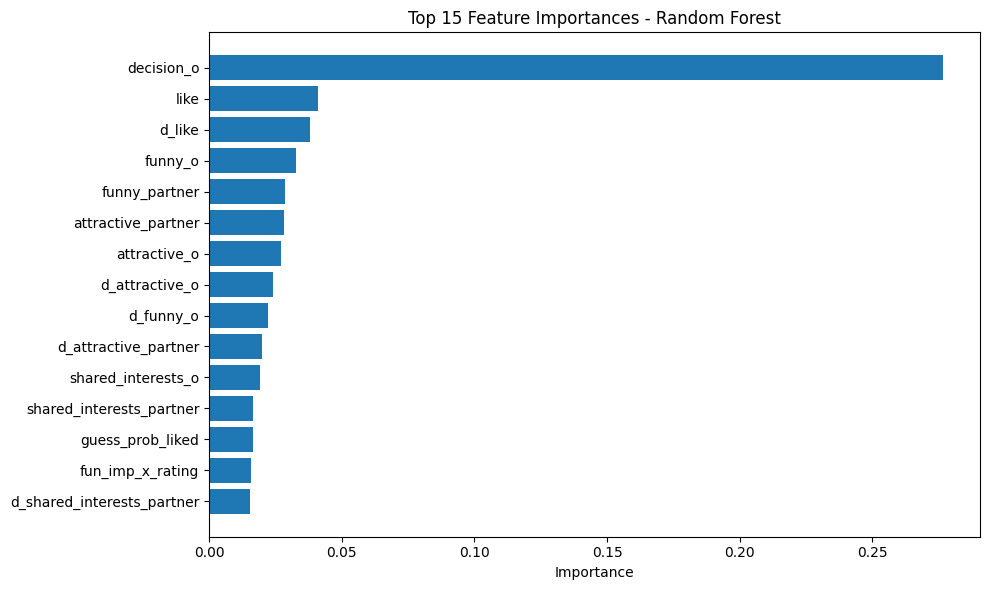

In [25]:
# Feature importance from Random Forest
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features (Random Forest):")
print(feature_importance_rf.head(15))

# Visualize top 15 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf.head(15)['feature'], 
         feature_importance_rf.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 4.2 XGBoost Classifier
Gradient boosting algorithm known for high performance on structured data.


In [26]:
# XGBoost with default parameters
xgb_default = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
evaluate_model(xgb_default, X_train, X_test, y_train, y_test, 
               'XGBoost (default)')



Model: XGBoost (default)
Test Accuracy:  0.9277
Precision:      0.8016
Recall:         0.7546
F1-Score:       0.7774
ROC-AUC:        0.9673
CV Accuracy:    0.9286 (+/- 0.0060)

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1358
           1       0.80      0.75      0.78       273

    accuracy                           0.93      1631
   macro avg       0.88      0.86      0.87      1631
weighted avg       0.93      0.93      0.93      1631



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [27]:
# Hyperparameter tuning for XGBoost
print("Tuning XGBoost hyperparameters...")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'scale_pos_weight': [1, scale_pos_weight]
}

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_random.best_params_}")
print(f"Best CV F1-score: {xgb_random.best_score_:.4f}")

# Evaluate the best model
evaluate_model(xgb_random.best_estimator_, X_train, X_test, y_train, y_test, 
               'XGBoost (tuned)', use_cv=True)


Tuning XGBoost hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'subsample': 1.0, 'scale_pos_weight': np.float64(4.9743589743589745), 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV F1-score: 0.7888

Model: XGBoost (tuned)
Test Accuracy:  0.9283
Precision:      0.7671
Recall:         0.8205
F1-Score:       0.7929
ROC-AUC:        0.9697
CV Accuracy:    0.9278 (+/- 0.0072)

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1358
           1       0.77      0.82      0.79       273

    accuracy                           0.93      1631
   macro avg       0.87      0.89      0.87      1631
weighted avg       0.93      0.93      0.93      1631



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'



Top 15 Most Important Features (XGBoost):
                          feature  importance
118                    decision_o    0.474218
115                        d_like    0.061566
66           d_attractive_partner    0.030435
113                          like    0.015219
60             attractive_partner    0.014009
69                d_funny_partner    0.013736
32                 d_attractive_o    0.012545
49   d_shared_interests_important    0.011839
97                     d_clubbing    0.011215
105                        d_yoga    0.010777
34               d_intelligence_o    0.008728
91                     d_exercise    0.007138
109          expected_num_matches    0.006481
63                  funny_partner    0.006479
56                      d_sincere    0.006081


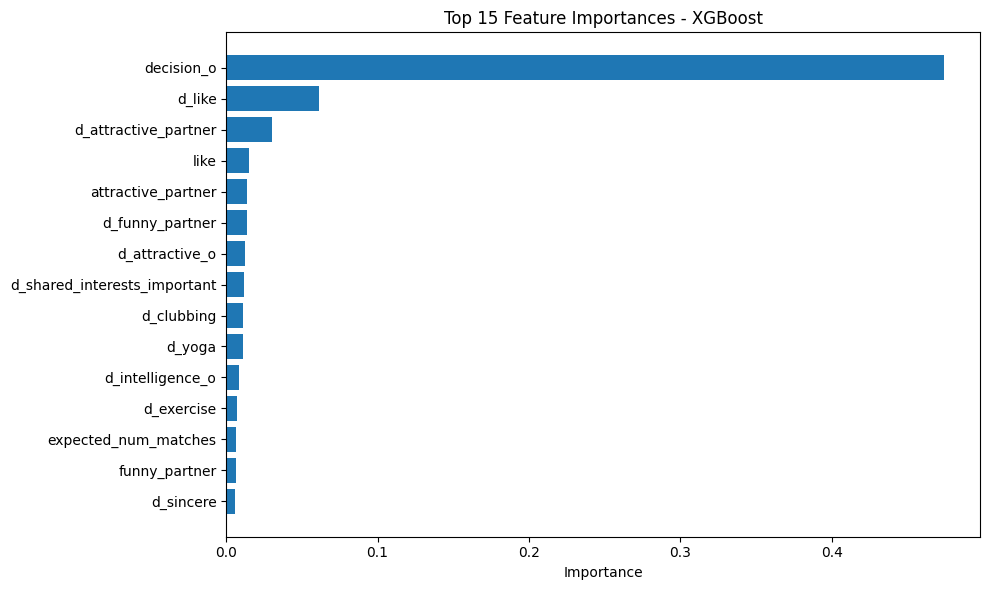

In [28]:
# Feature importance from XGBoost
feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_random.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(15))

# Visualize top 15 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_xgb.head(15)['feature'], 
         feature_importance_xgb.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 4.3 Neural Network (MLP)
Multi-layer perceptron for capturing complex non-linear patterns.


In [29]:
# MLP with default parameters
mlp_default = MLPClassifier(random_state=42, max_iter=500)
evaluate_model(mlp_default, X_train, X_test, y_train, y_test, 
               'Neural Network (default)')



Model: Neural Network (default)
Test Accuracy:  0.9123
Precision:      0.7539
Recall:         0.7070
F1-Score:       0.7297
ROC-AUC:        0.9488
CV Accuracy:    0.9145 (+/- 0.0058)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1358
           1       0.75      0.71      0.73       273

    accuracy                           0.91      1631
   macro avg       0.85      0.83      0.84      1631
weighted avg       0.91      0.91      0.91      1631



,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


In [30]:
# Hyperparameter tuning for MLP
print("Tuning Neural Network hyperparameters...")

param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [0.001, 0.01]
}

mlp_random = RandomizedSearchCV(
    MLPClassifier(random_state=42, max_iter=1000, early_stopping=True),
    param_distributions=param_dist_mlp,
    n_iter=15,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

mlp_random.fit(X_train, y_train)

print(f"\nBest parameters: {mlp_random.best_params_}")
print(f"Best CV F1-score: {mlp_random.best_score_:.4f}")

# Evaluate the best model
evaluate_model(mlp_random.best_estimator_, X_train, X_test, y_train, y_test, 
               'Neural Network (tuned)', use_cv=True)


Tuning Neural Network hyperparameters...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters: {'learning_rate_init': 0.001, 'learning_rate': 'constant', 'hidden_layer_sizes': (100,), 'alpha': 0.0001, 'activation': 'tanh'}
Best CV F1-score: 0.7360

Model: Neural Network (tuned)
Test Accuracy:  0.9062
Precision:      0.7344
Recall:         0.6886
F1-Score:       0.7108
ROC-AUC:        0.9482
CV Accuracy:    0.9148 (+/- 0.0108)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1358
           1       0.73      0.69      0.71       273

    accuracy                           0.91      1631
   macro avg       0.84      0.82      0.83      1631
weighted avg       0.90      0.91      0.90      1631



,hidden_layer_sizes,"(100,)"
,activation,'tanh'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


## 5. Comprehensive Evaluation

### 5.1 Confusion Matrix Comparison
Visualize confusion matrices for the top models.


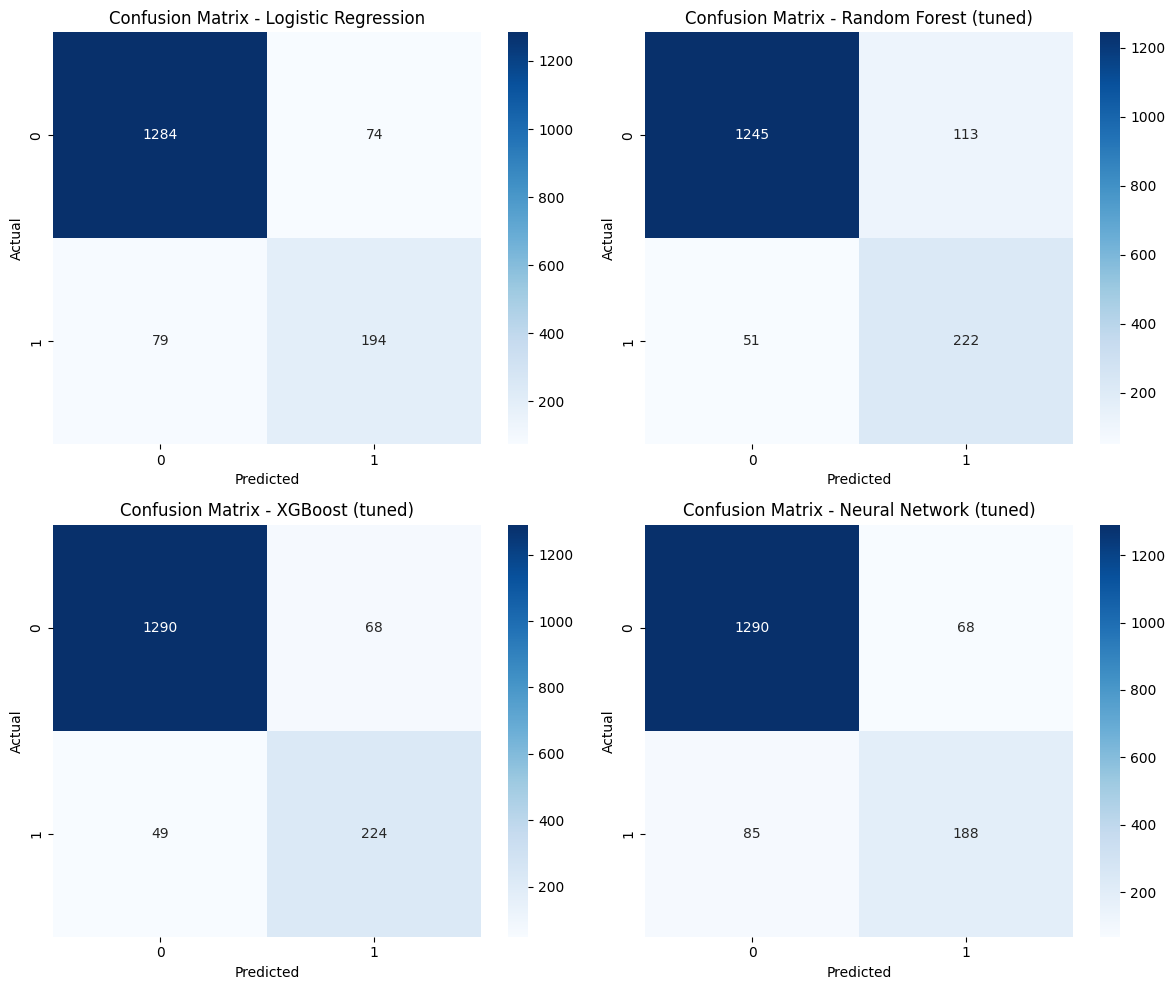

In [31]:
# Select top 4 models for detailed comparison
top_models = [
    ('Logistic Regression', lr),
    ('Random Forest (tuned)', rf_random.best_estimator_),
    ('XGBoost (tuned)', xgb_random.best_estimator_),
    ('Neural Network (tuned)', mlp_random.best_estimator_)
]

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(top_models):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    
plt.tight_layout()
plt.show()


### 5.2 ROC Curves
Compare ROC curves and AUC scores across models.


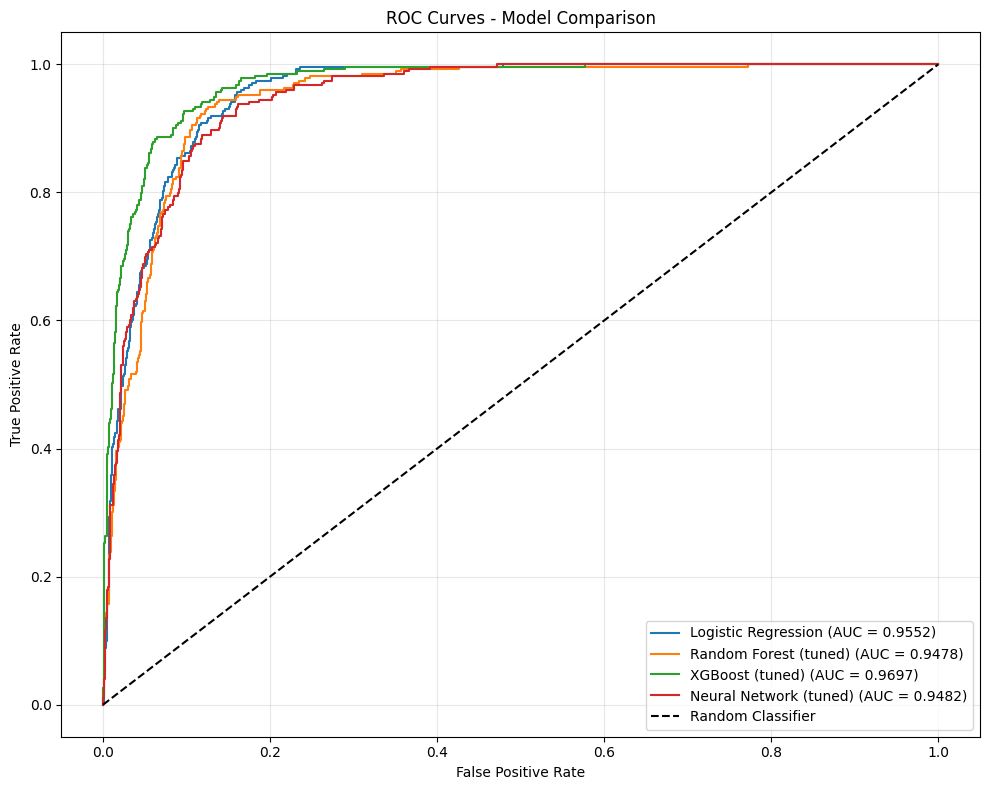

In [32]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

for name, model in top_models:
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Model Comparison and Results

### 6.1 Results Summary Table
Comprehensive comparison of all models.


In [33]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)

# Display with nice formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("="*100)
print("COMPREHENSIVE MODEL COMPARISON RESULTS")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)


COMPREHENSIVE MODEL COMPARISON RESULTS
                             Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV_Mean  CV_Std
                   XGBoost (tuned)    0.9283     0.7671  0.8205    0.7929   0.9697   0.9278  0.0072
                 XGBoost (default)    0.9277     0.8016  0.7546    0.7774   0.9673   0.9286  0.0060
          Neural Network (default)    0.9123     0.7539  0.7070    0.7297   0.9488   0.9145  0.0058
               Logistic Regression    0.9062     0.7239  0.7106    0.7172   0.9552   0.9183  0.0118
            Neural Network (tuned)    0.9062     0.7344  0.6886    0.7108   0.9482   0.9148  0.0108
             Random Forest (tuned)    0.8994     0.6627  0.8132    0.7303   0.9478   0.8998  0.0075
                  Ridge Classifier    0.8976     0.8011  0.5165    0.6281      NaN   0.8987  0.0054
           Random Forest (default)    0.8909     0.7950  0.4689    0.5899   0.9542   0.8999  0.0032
       Logistic Regression + SMOTE    0.8853     0.6049  0.90

### 📝 Note on NaN Values

**Two models show NaN for ROC-AUC:**

1. **Ridge Classifier**: This is a hard classifier that doesn't support probability predictions (`predict_proba`). ROC-AUC requires probability scores to compute the curve, so it cannot be calculated for this model.

2. **Rule-based (decision_o)**: This is a simple threshold-based rule that outputs binary predictions only. It also lacks probability estimates needed for ROC-AUC calculation.

**This is expected behavior** for hard classifiers and rule-based models. All other metrics (Accuracy, Precision, Recall, F1-Score, CV scores) are available and valid for these models.

**Note**: All advanced models (XGBoost, Random Forest, Neural Network, Logistic Regression) support probability predictions and have complete ROC-AUC scores.

### 6.2 Visual Comparison of Model Performance


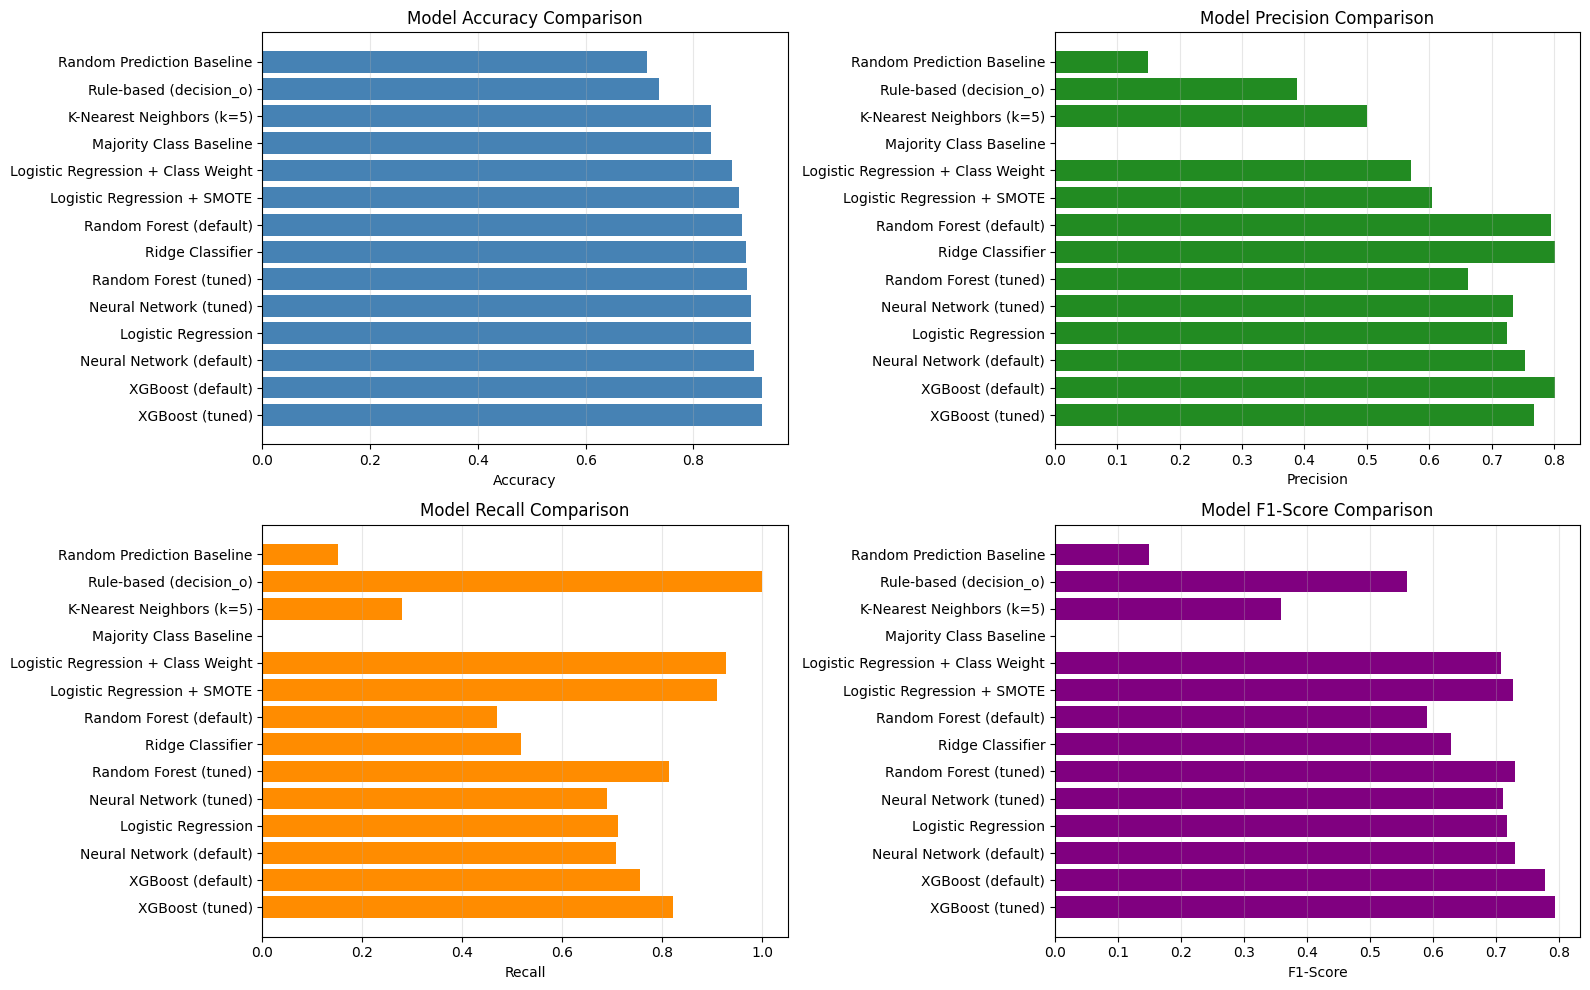

In [34]:
# Create a visual comparison of key metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Accuracy comparison
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].grid(axis='x', alpha=0.3)

# Precision comparison
axes[0, 1].barh(results_df['Model'], results_df['Precision'], color='forestgreen')
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_title('Model Precision Comparison')
axes[0, 1].grid(axis='x', alpha=0.3)

# Recall comparison
axes[1, 0].barh(results_df['Model'], results_df['Recall'], color='darkorange')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_title('Model Recall Comparison')
axes[1, 0].grid(axis='x', alpha=0.3)

# F1-Score comparison
axes[1, 1].barh(results_df['Model'], results_df['F1-Score'], color='purple')
axes[1, 1].set_xlabel('F1-Score')
axes[1, 1].set_title('Model F1-Score Comparison')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### 6.3 Best Model Selection


In [35]:
# Identify best model
best_model_row = results_df.iloc[0]
print("="*100)
print("BEST MODEL SELECTION")
print("="*100)
print(f"\nBest Model: {best_model_row['Model']}")
print(f"\nPerformance Metrics:")
print(f"  - Accuracy:  {best_model_row['Accuracy']:.4f}")
print(f"  - Precision: {best_model_row['Precision']:.4f}")
print(f"  - Recall:    {best_model_row['Recall']:.4f}")
print(f"  - F1-Score:  {best_model_row['F1-Score']:.4f}")
if best_model_row['ROC-AUC'] is not None:
    print(f"  - ROC-AUC:   {best_model_row['ROC-AUC']:.4f}")
if best_model_row['CV_Mean'] is not None:
    print(f"  - CV Acc:    {best_model_row['CV_Mean']:.4f} (+/- {best_model_row['CV_Std']:.4f})")
print("="*100)

# Compare with baseline from data_analysis.ipynb
baseline_accuracy = 0.9086  # From teammate's analysis
improvement = (best_model_row['Accuracy'] - baseline_accuracy) * 100
print(f"\nImprovement over baseline: {improvement:+.2f}%")
print(f"Baseline (from data_analysis.ipynb): {baseline_accuracy:.4f}")
print(f"Best Model: {best_model_row['Accuracy']:.4f}")


BEST MODEL SELECTION

Best Model: XGBoost (tuned)

Performance Metrics:
  - Accuracy:  0.9283
  - Precision: 0.7671
  - Recall:    0.8205
  - F1-Score:  0.7929
  - ROC-AUC:   0.9697
  - CV Acc:    0.9278 (+/- 0.0072)

Improvement over baseline: +1.97%
Baseline (from data_analysis.ipynb): 0.9086
Best Model: 0.9283
